# Data_Exploration_and_Cleaning

## 📦 Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

In [2]:
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "#0f0f0f",
    "axes.facecolor": "#1a1a2e",
    "axes.edgecolor": "#444",
    "axes.labelcolor": "white",
    "axes.titlecolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "text.color": "white",
    "grid.color": "#333",
    "legend.facecolor": "#1a1a2e",
    "legend.edgecolor": "#444",
    "legend.labelcolor": "white",
    "font.family": "DejaVu Sans",
})

ACCENT   = ["#7c83fd", "#fd7c7c", "#7cfd9e", "#fdd97c", "#fd7cdb"]
BURNOUT  = {"Low": "#7cfd9e", "Medium": "#fdd97c", "High": "#fd7c7c"}
POLICY   = {"Allowed_With_Citation":"#7c83fd","Strictly_Ban":"#fd7c7c","Actively_Encouraged":"#7cfd9e"}

print("✅ Setup complete")

✅ Setup complete


## Load & Preview Data

In [4]:
df = pd.read_csv("/content/ai_student_impact_dataset (1).csv")
# If running locally, change path above to your local path

print(f"Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(10)

Shape : 50,000 rows × 16 columns


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
5,100006,STEM,Junior,3.449,6.50,Debugging/Troubleshooting,Beginner,1,False,14.19,4,Allowed_With_Citation,5,3.666,65.92,High
6,100007,STEM,Freshman,3.622,31.41,Summarizing_Reading,Advanced,5,True,13.11,8,Allowed_With_Citation,7,4.000,67.97,Medium
7,100008,Arts,Junior,2.746,5.33,Copywriting/Drafting,Intermediate,3,False,18.45,2,Actively_Encouraged,1,2.965,85.09,Medium
8,100009,Business,Sophomore,3.420,2.00,Debugging/Troubleshooting,Beginner,2,True,2.87,1,Strict_Ban,5,3.396,55.71,Medium
9,100010,Business,Sophomore,3.046,19.99,Debugging/Troubleshooting,Intermediate,2,True,12.49,3,Strict_Ban,8,2.978,87.18,High


## 🔍 Data Overview

In [5]:
# ── Data types & non-null counts ─────────────────────────────────────────────
print("=" * 55)
print("COLUMN INFO")
print("=" * 55)
df.info()

COLUMN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA  

In [6]:
# ── Missing values ───────────────────────────────────────────────────────────
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "✅ No missing values found!")

Missing values per column:
✅ No missing values found!


In [7]:
# ── Statistical summary ──────────────────────────────────────────────────────
df.describe(include="all").T.style.background_gradient(cmap="Blues", axis=0)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Student_ID,50000.000000,nan,nan,nan,125000.500000,14433.901067,100001.000000,112500.750000,125000.500000,137500.250000,150000.000000
Major_Category,50000,5,STEM,15059,nan,nan,nan,nan,nan,nan,nan
Year_of_Study,50000,5,Junior,11045,nan,nan,nan,nan,nan,nan,nan
Pre_Semester_GPA,50000.000000,nan,nan,nan,3.146102,0.478854,1.183000,2.834000,3.210000,3.521000,3.998000
Weekly_GenAI_Hours,50000.000000,nan,nan,nan,8.427752,8.269490,0.000000,2.390000,5.800000,11.720000,40.000000
Primary_Use_Case,50000,5,Debugging/Troubleshooting,12295,nan,nan,nan,nan,nan,nan,nan
Prompt_Engineering_Skill,50000,3,Beginner,18495,nan,nan,nan,nan,nan,nan,nan
Tool_Diversity,50000.000000,nan,nan,nan,2.800260,1.188020,1.000000,2.000000,3.000000,4.000000,5.000000
Paid_Subscription,50000,2,False,28846,nan,nan,nan,nan,nan,nan,nan
Traditional_Study_Hours,50000.000000,nan,nan,nan,11.209271,5.156426,1.000000,7.560000,11.180000,14.710000,35.860000


In [8]:
# ── Categorical value counts ─────────────────────────────────────────────────
cat_cols = df.select_dtypes(include="object").columns.tolist()
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().to_string())


Major_Category:
Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933

Year_of_Study:
Year_of_Study
Junior       11045
Freshman     11031
Senior       10634
Sophomore     9860
Graduate      7430

Primary_Use_Case:
Primary_Use_Case
Debugging/Troubleshooting    12295
Copywriting/Drafting         12011
Ideation                     10721
Summarizing_Reading           8633
Direct_Answer_Generation      6340

Prompt_Engineering_Skill:
Prompt_Engineering_Skill
Beginner        18495
Intermediate    17696
Advanced        13809

Institutional_Policy:
Institutional_Policy
Allowed_With_Citation    25224
Actively_Encouraged      14988
Strict_Ban                9788

Burnout_Risk_Level:
Burnout_Risk_Level
Medium    21144
Low       16369
High      12487


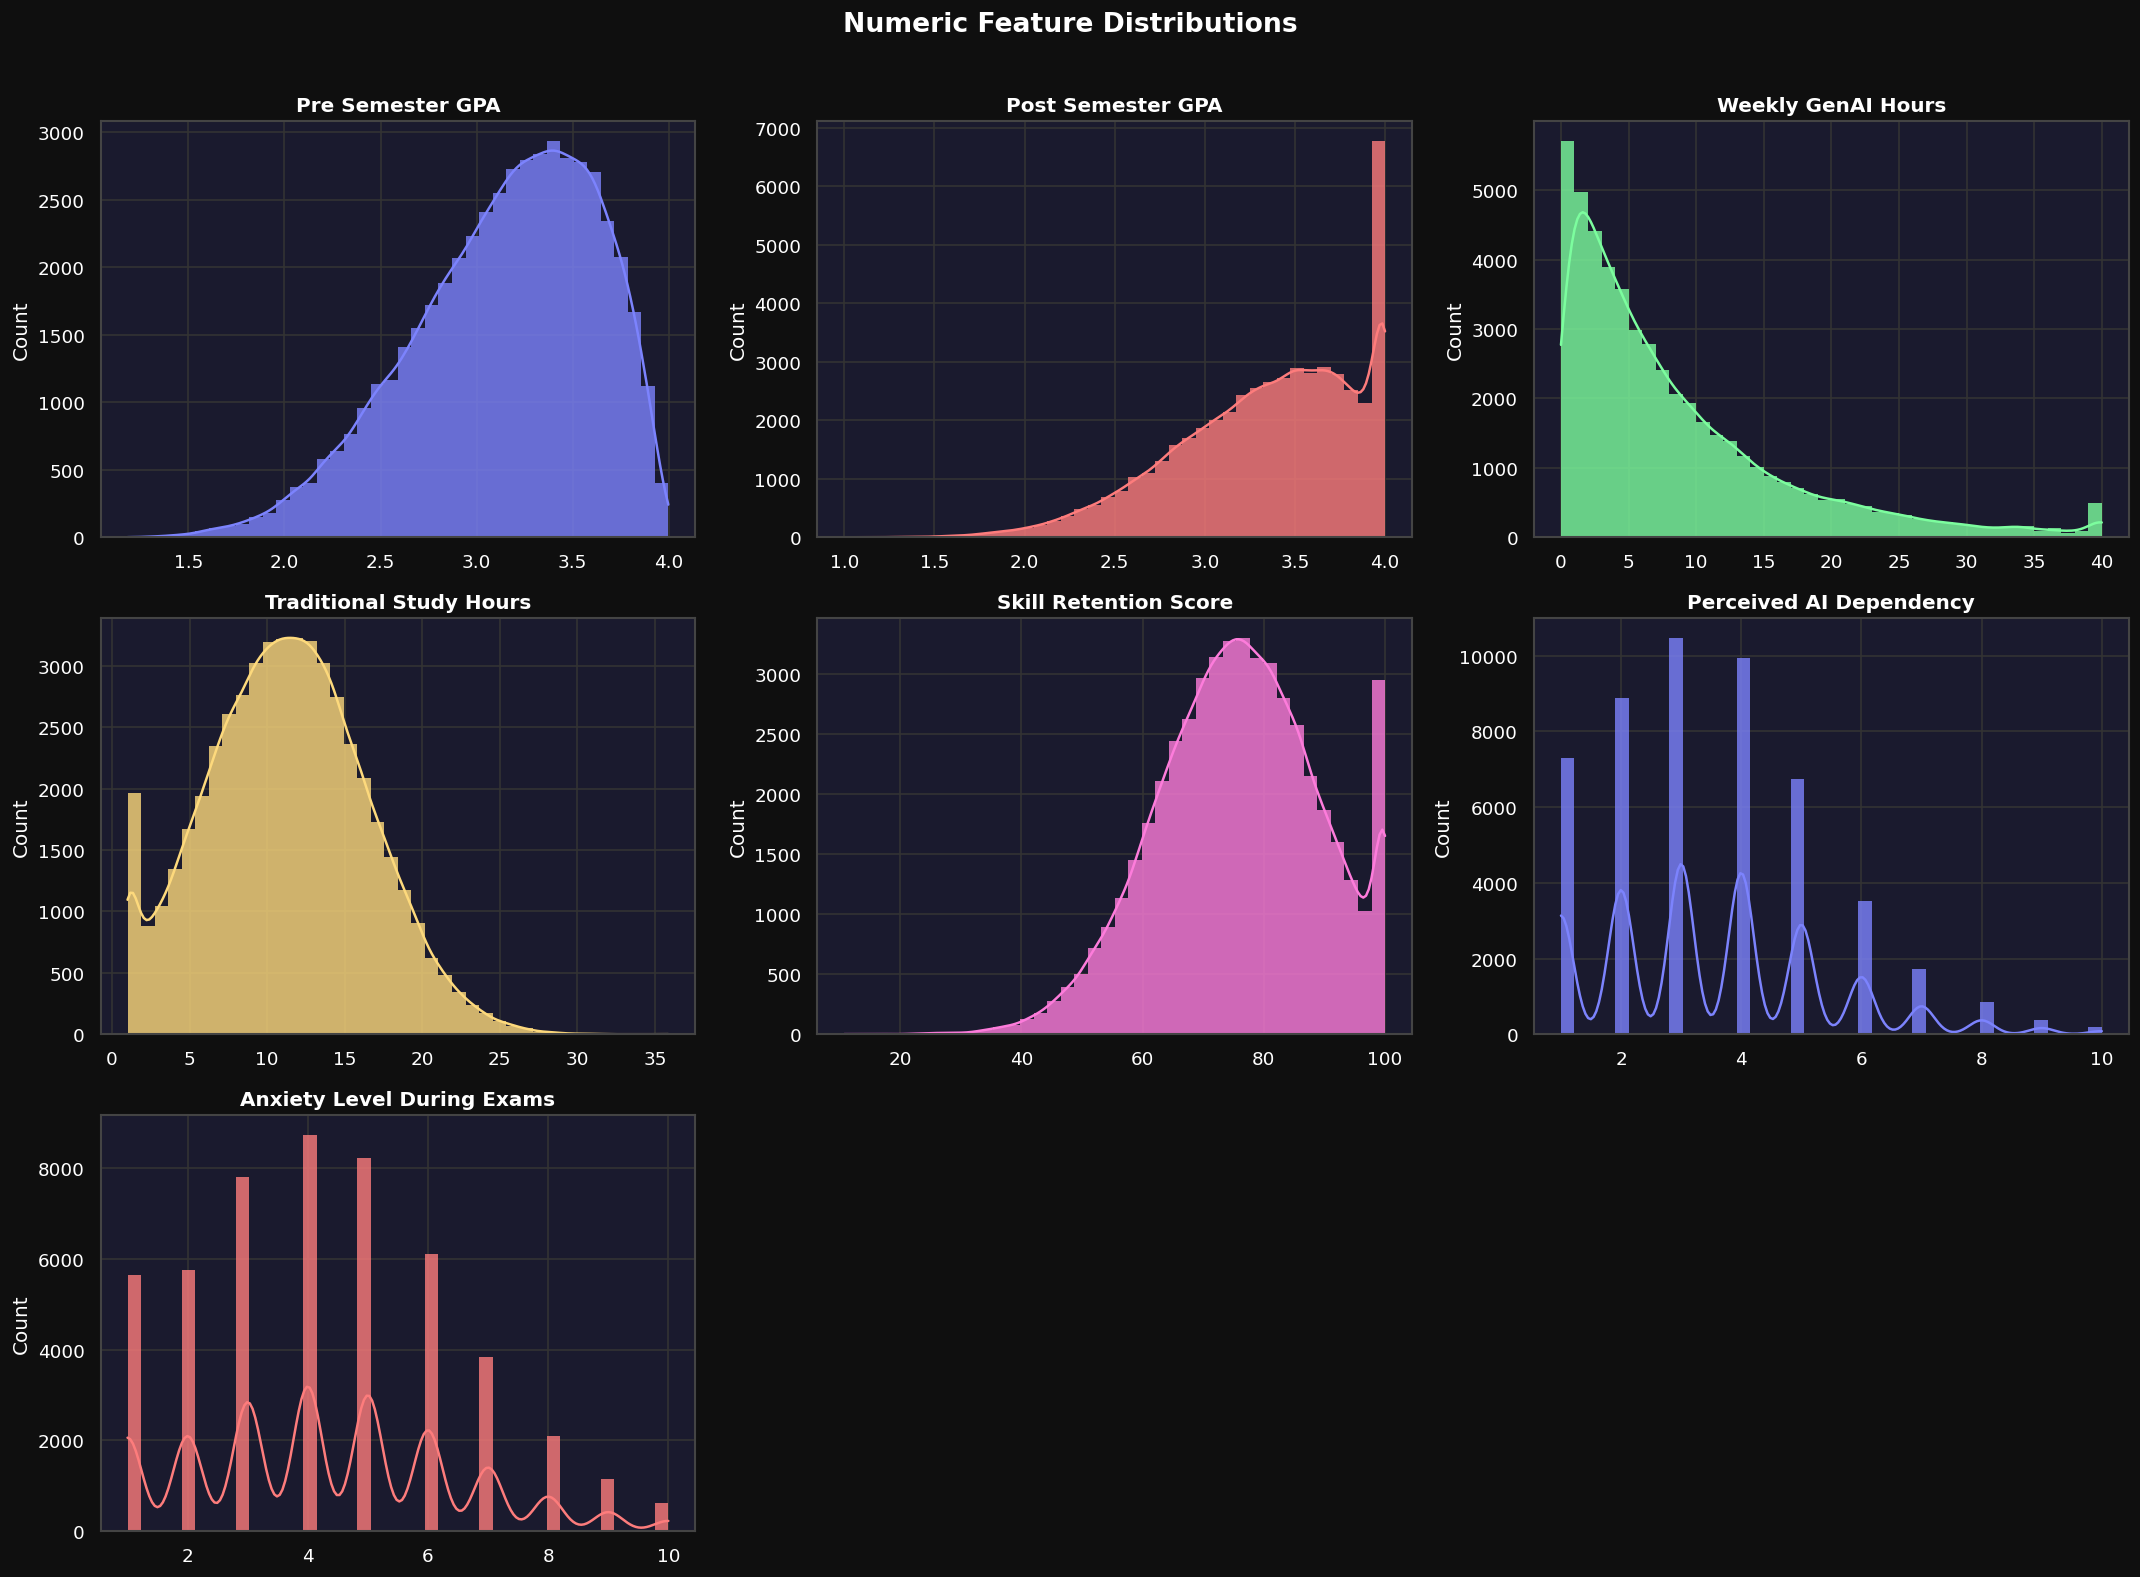

## 📊 Univariate Analysis — Distributions

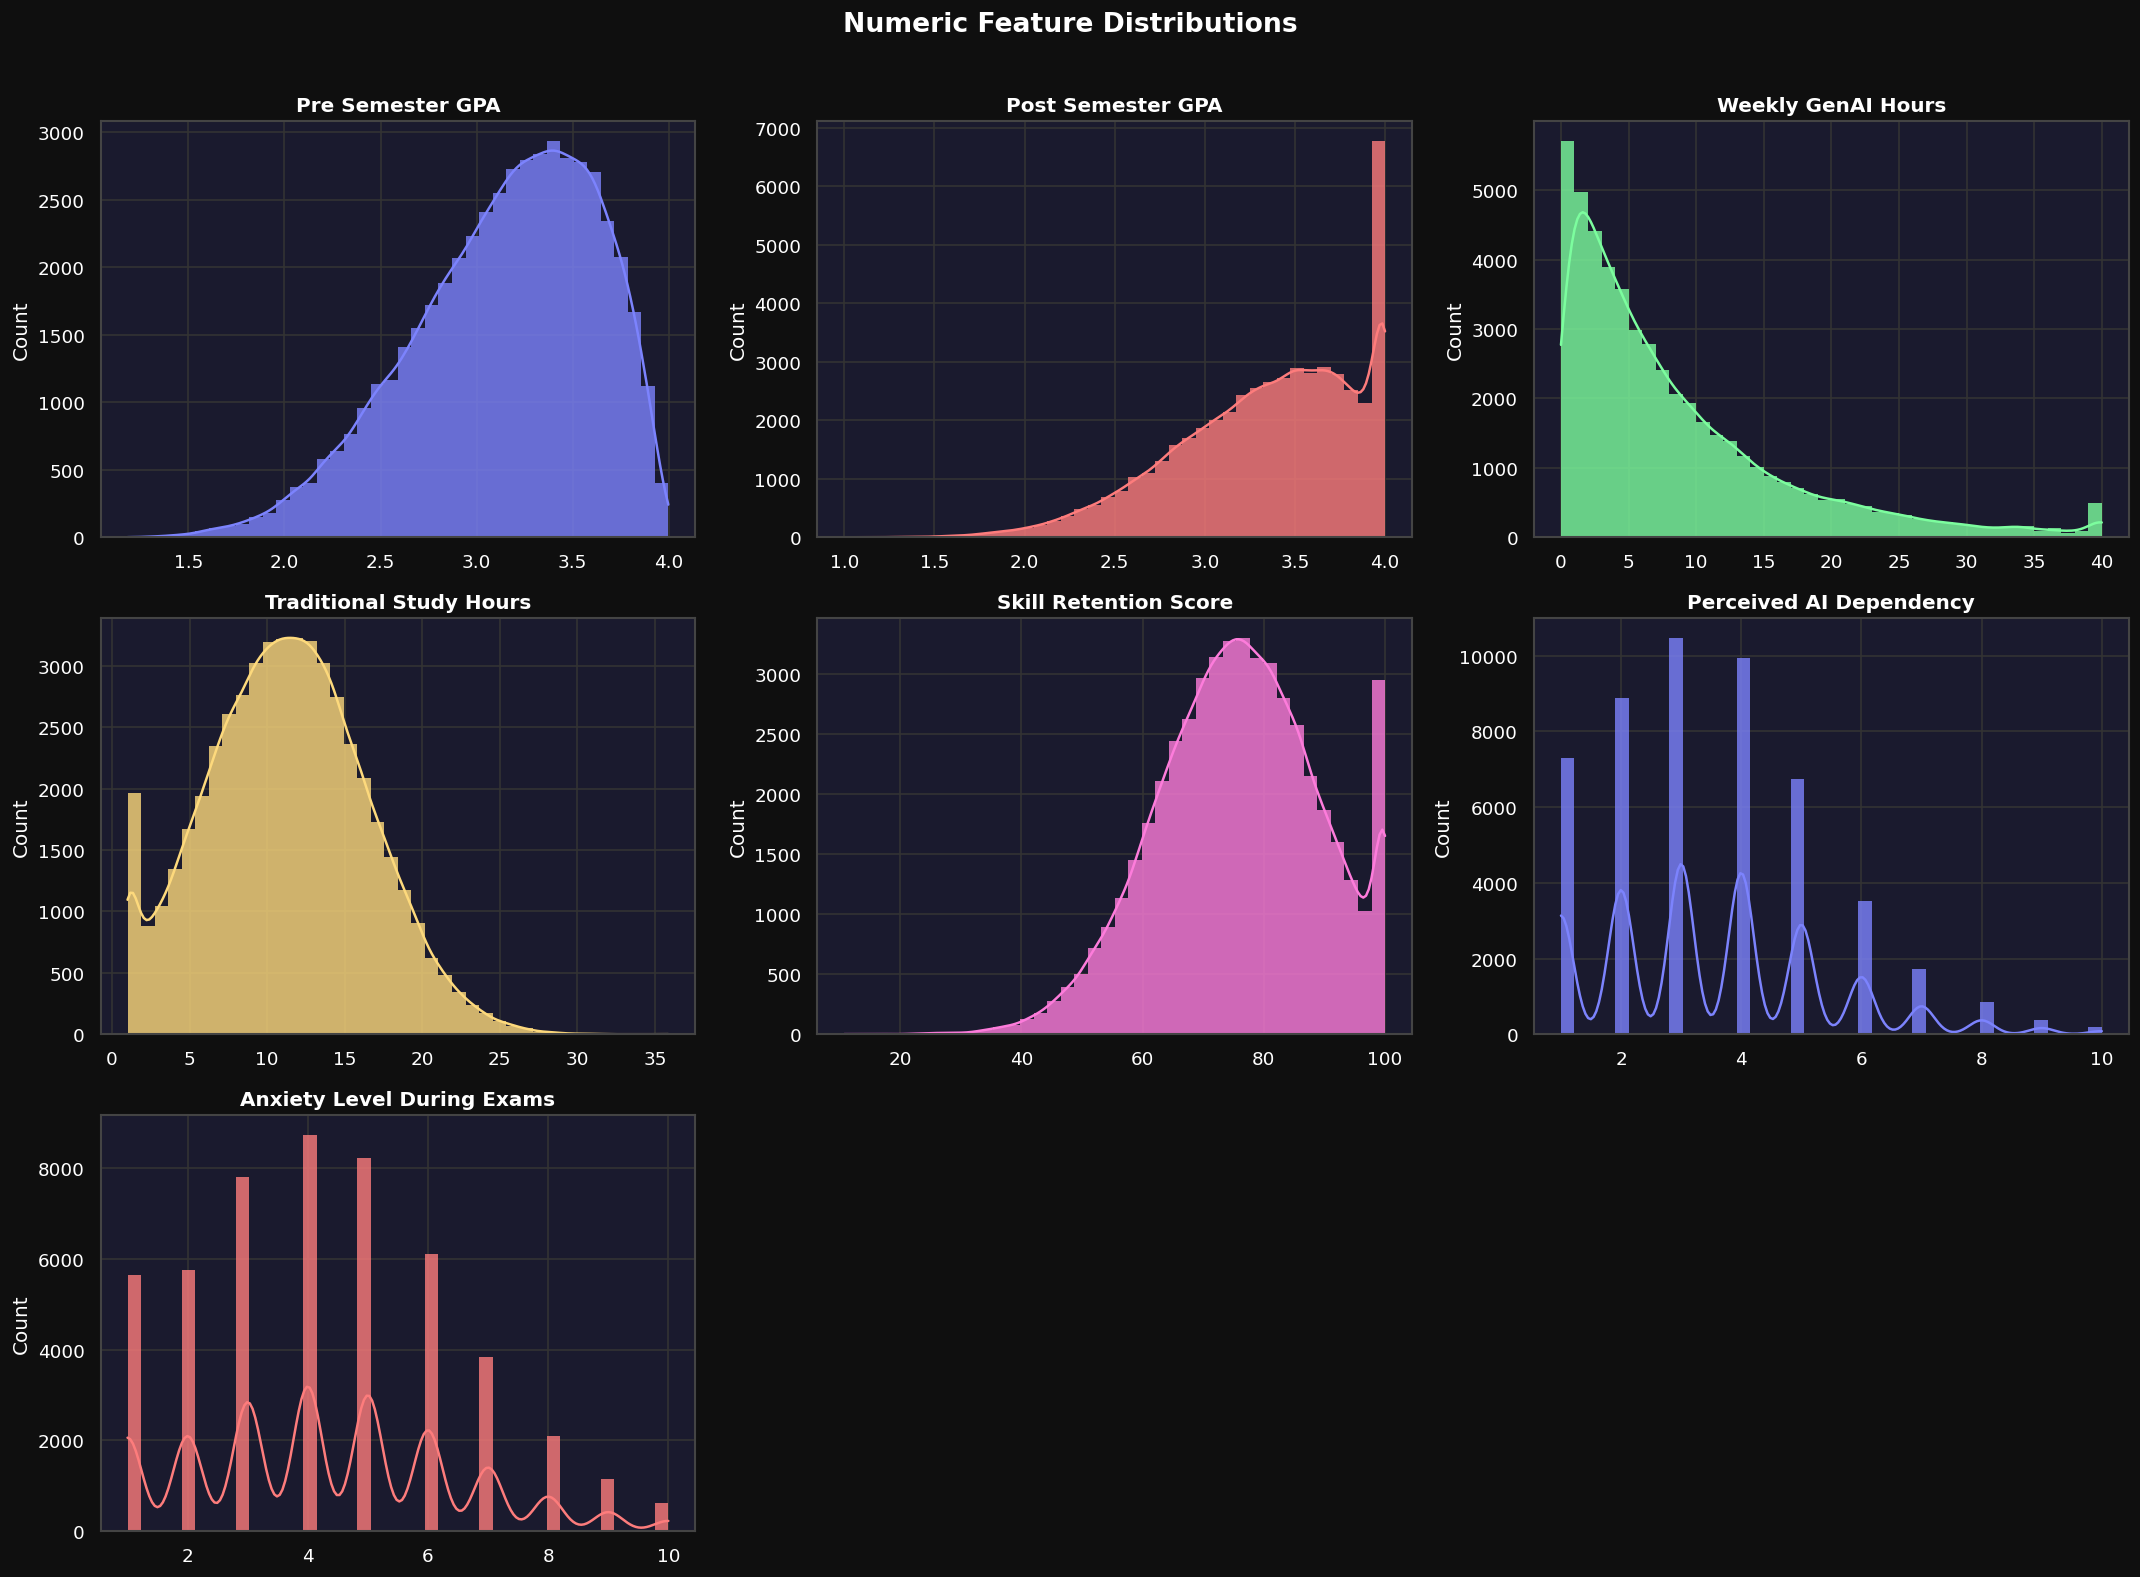

In [11]:
# ── Numeric distributions ────────────────────────────────────────────────────
num_cols = ["Pre_Semester_GPA","Post_Semester_GPA","Weekly_GenAI_Hours",
            "Traditional_Study_Hours","Skill_Retention_Score",
            "Perceived_AI_Dependency","Anxiety_Level_During_Exams"]

fig, axes = plt.subplots(3, 3, figsize=(18, 13))
fig.suptitle("Numeric Feature Distributions", fontsize=16, fontweight="bold", y=1.01)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.histplot(df[col], bins=40, kde=True, ax=ax,
                 color=ACCENT[i % len(ACCENT)], edgecolor="none", alpha=0.8)
    ax.set_title(col.replace("_", " "), fontweight="bold")
    ax.set_xlabel("")

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

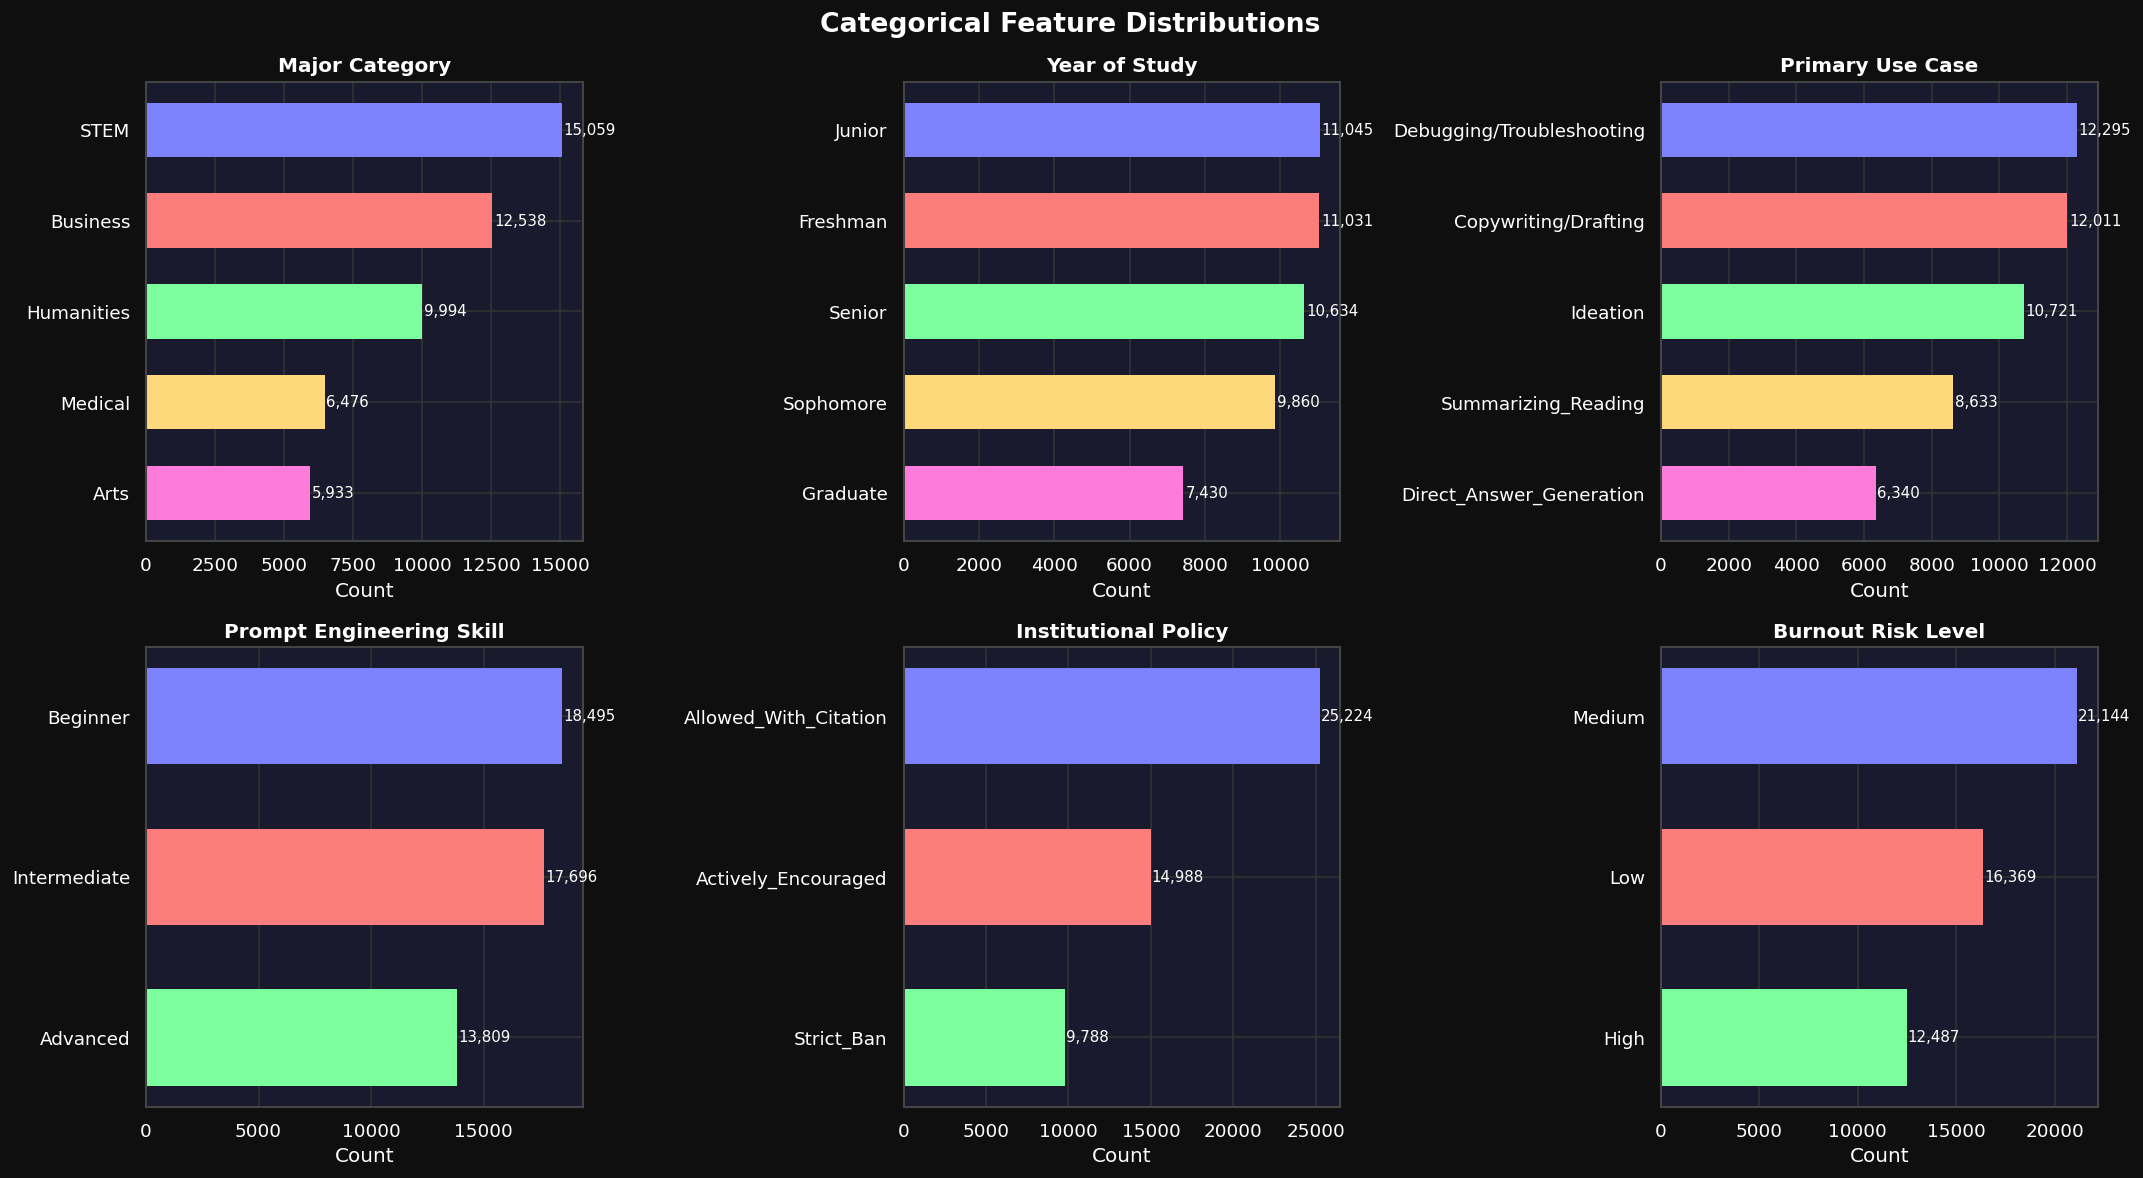

In [10]:
# ── Categorical distributions ────────────────────────────────────────────────
cat_display = ["Major_Category","Year_of_Study","Primary_Use_Case",
               "Prompt_Engineering_Skill","Institutional_Policy","Burnout_Risk_Level"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Categorical Feature Distributions", fontsize=16, fontweight="bold")
axes = axes.flatten()

for i, col in enumerate(cat_display):
    ax = axes[i]
    counts = df[col].value_counts()
    bars = ax.barh(counts.index, counts.values,
                   color=[ACCENT[j % len(ACCENT)] for j in range(len(counts))],
                   edgecolor="none", height=0.6)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                f"{val:,}", va="center", ha="left", fontsize=9, color="white")
    ax.set_title(col.replace("_", " "), fontweight="bold")
    ax.set_xlabel("Count")
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 🤖 AI Usage Patterns

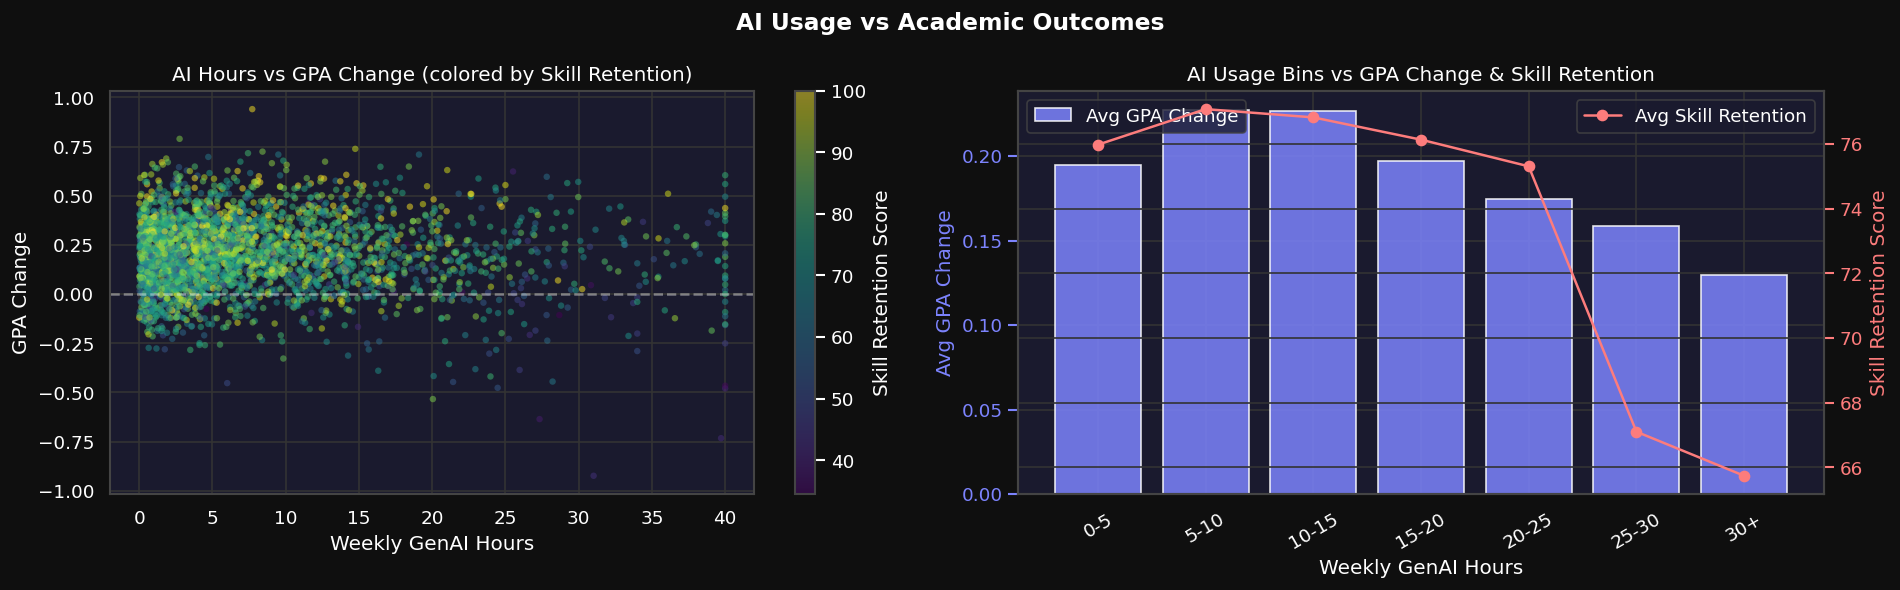

In [13]:
# ── AI hours vs GPA Change ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("AI Usage vs Academic Outcomes", fontsize=14, fontweight="bold")

# Calculate GPA Change
df['GPA_Change'] = df['Post_Semester_GPA'] - df['Pre_Semester_GPA']

# Scatter: AI hours vs GPA change (sampled for clarity)
sample = df.sample(3000, random_state=42)
sc = axes[0].scatter(sample["Weekly_GenAI_Hours"], sample["GPA_Change"],
                     c=sample["Skill_Retention_Score"], cmap="viridis",
                     alpha=0.5, s=15, edgecolors="none")
plt.colorbar(sc, ax=axes[0], label="Skill Retention Score")
axes[0].axhline(0, color="white", linestyle="--", alpha=0.4)
axes[0].set_xlabel("Weekly GenAI Hours")
axes[0].set_ylabel("GPA Change")
axes[0].set_title("AI Hours vs GPA Change (colored by Skill Retention)")

# Binned average
df["AI_Bin"] = pd.cut(df["Weekly_GenAI_Hours"],
                      bins=[0,5,10,15,20,25,30,40],
                      labels=["0-5","5-10","10-15","15-20","20-25","25-30","30+"])
binned = df.groupby("AI_Bin", observed=True).agg(
    GPA_Change=("GPA_Change","mean"),
    Skill_Ret=("Skill_Retention_Score","mean")
).reset_index()
x = range(len(binned))
axes[1].bar(x, binned["GPA_Change"], color="#7c83fd", label="Avg GPA Change", alpha=0.85)
ax2 = axes[1].twinx()
ax2.plot(x, binned["Skill_Ret"], color="#fd7c7c", marker="o", label="Avg Skill Retention")
ax2.set_ylabel("Skill Retention Score", color="#fd7c7c")
ax2.tick_params(colors="#fd7c7c")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(binned["AI_Bin"].astype(str), rotation=30)
axes[1].set_xlabel("Weekly GenAI Hours")
axes[1].set_ylabel("Avg GPA Change", color="#7c83fd")
axes[1].tick_params(axis="y", colors="#7c83fd")
axes[1].set_title("AI Usage Bins vs GPA Change & Skill Retention")
axes[1].legend(loc="upper left")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()


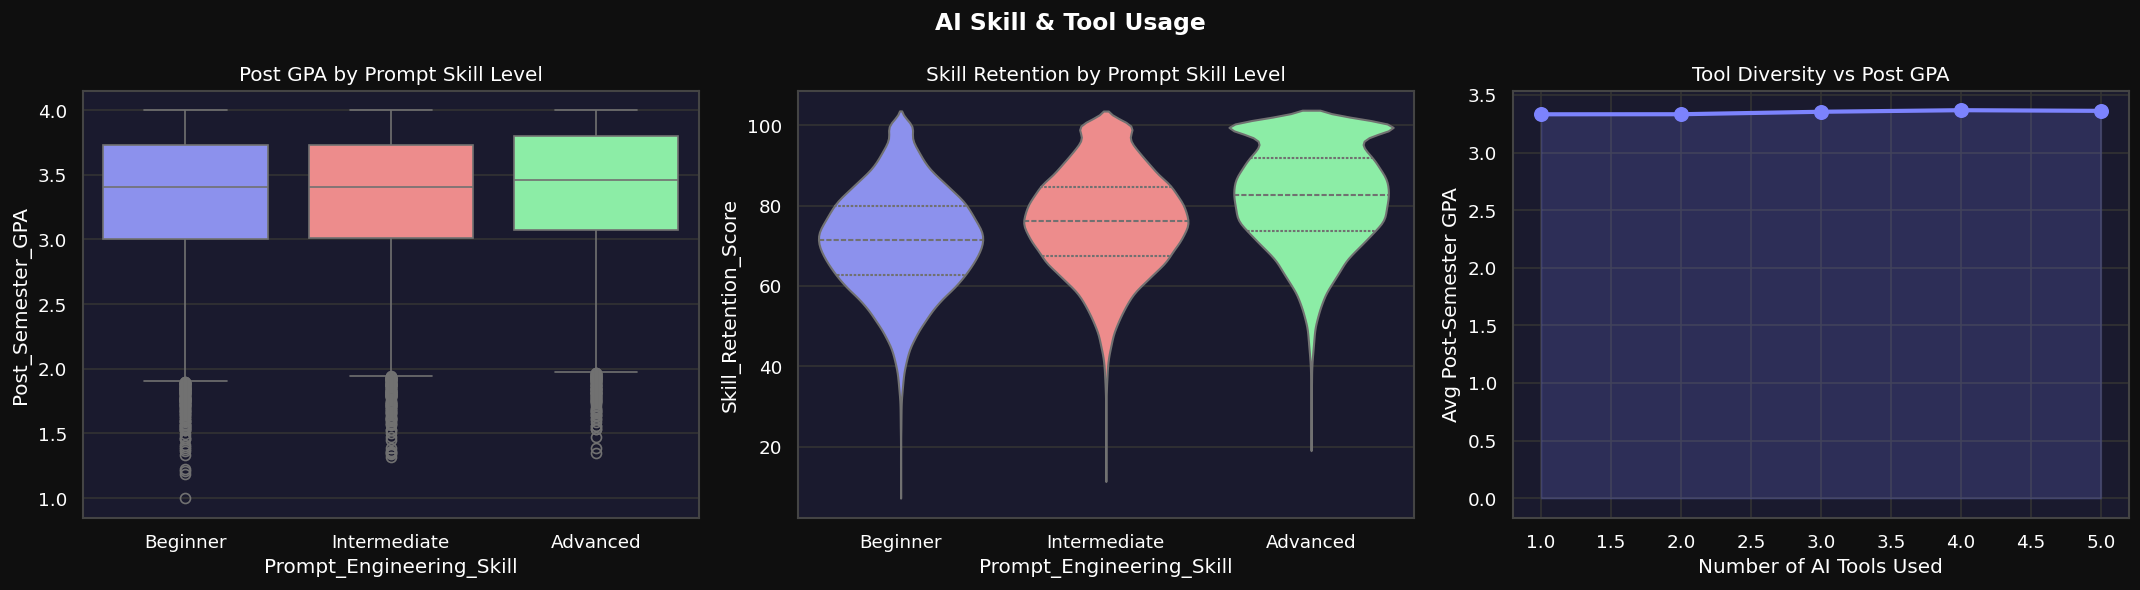

In [14]:
# ── Prompt skill & Tool diversity ────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("AI Skill & Tool Usage", fontsize=14, fontweight="bold")

skill_order = ["Beginner","Intermediate","Advanced"]

# GPA by Prompt Skill
sns.boxplot(data=df, x="Prompt_Engineering_Skill", y="Post_Semester_GPA",
            order=skill_order, palette=ACCENT[:3], ax=axes[0])
axes[0].set_title("Post GPA by Prompt Skill Level")

# Skill retention by Prompt Skill
sns.violinplot(data=df, x="Prompt_Engineering_Skill", y="Skill_Retention_Score",
               order=skill_order, palette=ACCENT[:3], ax=axes[1], inner="quartile")
axes[1].set_title("Skill Retention by Prompt Skill Level")

# Tool diversity vs GPA
td = df.groupby("Tool_Diversity")["Post_Semester_GPA"].mean()
axes[2].plot(td.index, td.values, marker="o", color="#7c83fd", linewidth=2.5, markersize=8)
axes[2].fill_between(td.index, td.values, alpha=0.2, color="#7c83fd")
axes[2].set_xlabel("Number of AI Tools Used")
axes[2].set_ylabel("Avg Post-Semester GPA")
axes[2].set_title("Tool Diversity vs Post GPA")

plt.tight_layout()
plt.show()


## 🧠 Student Well-being — Burnout, Anxiety & Dependency

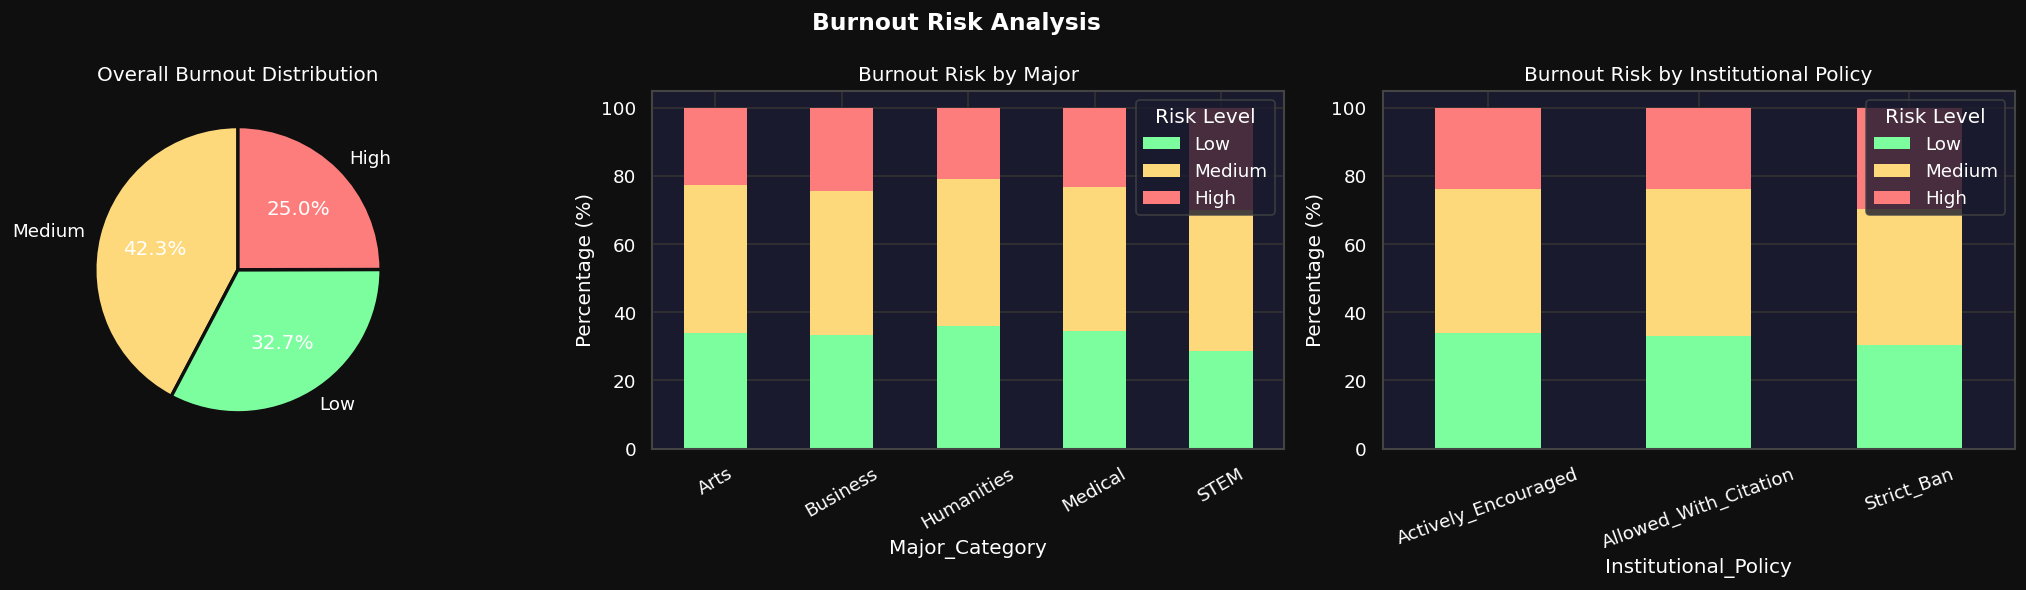

In [15]:
# ── Burnout risk breakdown ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Burnout Risk Analysis", fontsize=14, fontweight="bold")

# Overall pie
burnout_counts = df["Burnout_Risk_Level"].value_counts()
axes[0].pie(burnout_counts.values,
            labels=burnout_counts.index,
            colors=[BURNOUT[k] for k in burnout_counts.index],
            autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor":"#0f0f0f","linewidth":2})
axes[0].set_title("Overall Burnout Distribution")

# Burnout by Major
major_burnout = df.groupby(["Major_Category","Burnout_Risk_Level"]).size().unstack()
major_burnout_pct = major_burnout.div(major_burnout.sum(axis=1), axis=0) * 100
major_burnout_pct[["Low","Medium","High"]].plot(
    kind="bar", ax=axes[1], stacked=True,
    color=[BURNOUT["Low"], BURNOUT["Medium"], BURNOUT["High"]],
    edgecolor="none")
axes[1].set_title("Burnout Risk by Major")
axes[1].set_ylabel("Percentage (%)")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="Risk Level", loc="upper right")

# Burnout by Institutional Policy
policy_burnout = df.groupby(["Institutional_Policy","Burnout_Risk_Level"]).size().unstack()
policy_burnout_pct = policy_burnout.div(policy_burnout.sum(axis=1), axis=0) * 100
policy_burnout_pct[["Low","Medium","High"]].plot(
    kind="bar", ax=axes[2], stacked=True,
    color=[BURNOUT["Low"], BURNOUT["Medium"], BURNOUT["High"]],
    edgecolor="none")
axes[2].set_title("Burnout Risk by Institutional Policy")
axes[2].set_ylabel("Percentage (%)")
axes[2].tick_params(axis="x", rotation=20)
axes[2].legend(title="Risk Level", loc="upper right")

plt.tight_layout()
plt.show()

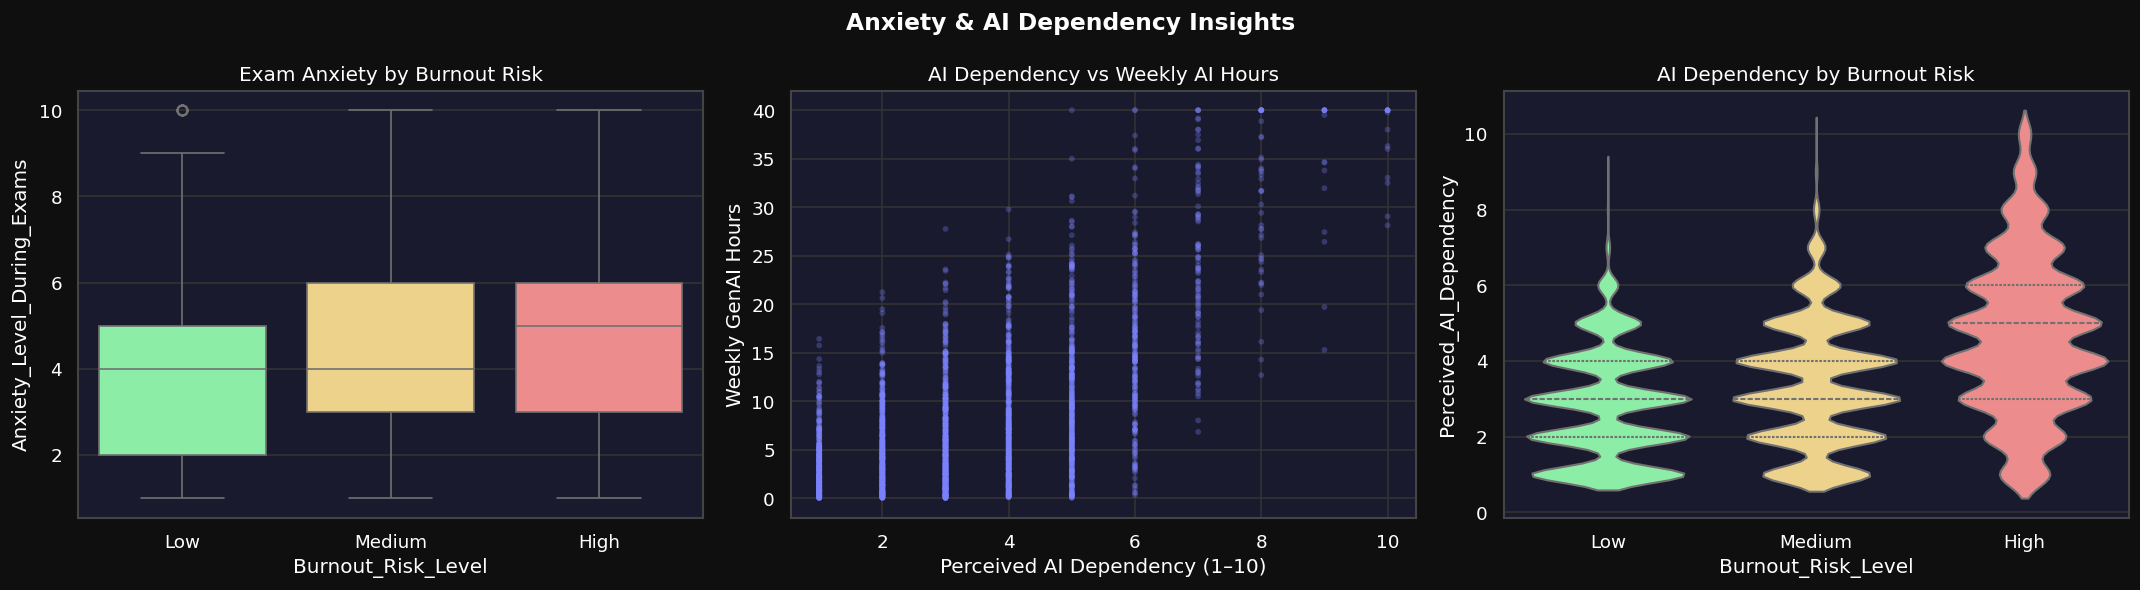

In [16]:
# ── Anxiety & Dependency ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Anxiety & AI Dependency Insights", fontsize=14, fontweight="bold")

# Anxiety by Burnout
sns.boxplot(data=df, x="Burnout_Risk_Level", y="Anxiety_Level_During_Exams",
            order=["Low","Medium","High"],
            palette=[BURNOUT["Low"],BURNOUT["Medium"],BURNOUT["High"]], ax=axes[0])
axes[0].set_title("Exam Anxiety by Burnout Risk")

# Dependency vs AI Hours
axes[1].scatter(df.sample(3000, random_state=1)["Perceived_AI_Dependency"],
                df.sample(3000, random_state=1)["Weekly_GenAI_Hours"],
                alpha=0.3, s=12, color="#7c83fd", edgecolors="none")
axes[1].set_xlabel("Perceived AI Dependency (1–10)")
axes[1].set_ylabel("Weekly GenAI Hours")
axes[1].set_title("AI Dependency vs Weekly AI Hours")

# Dependency by Burnout
sns.violinplot(data=df, x="Burnout_Risk_Level", y="Perceived_AI_Dependency",
               order=["Low","Medium","High"],
               palette=[BURNOUT["Low"],BURNOUT["Medium"],BURNOUT["High"]],
               ax=axes[2], inner="quartile")
axes[2].set_title("AI Dependency by Burnout Risk")

plt.tight_layout()
plt.show()


## 🏛️ Institutional Policy Impact

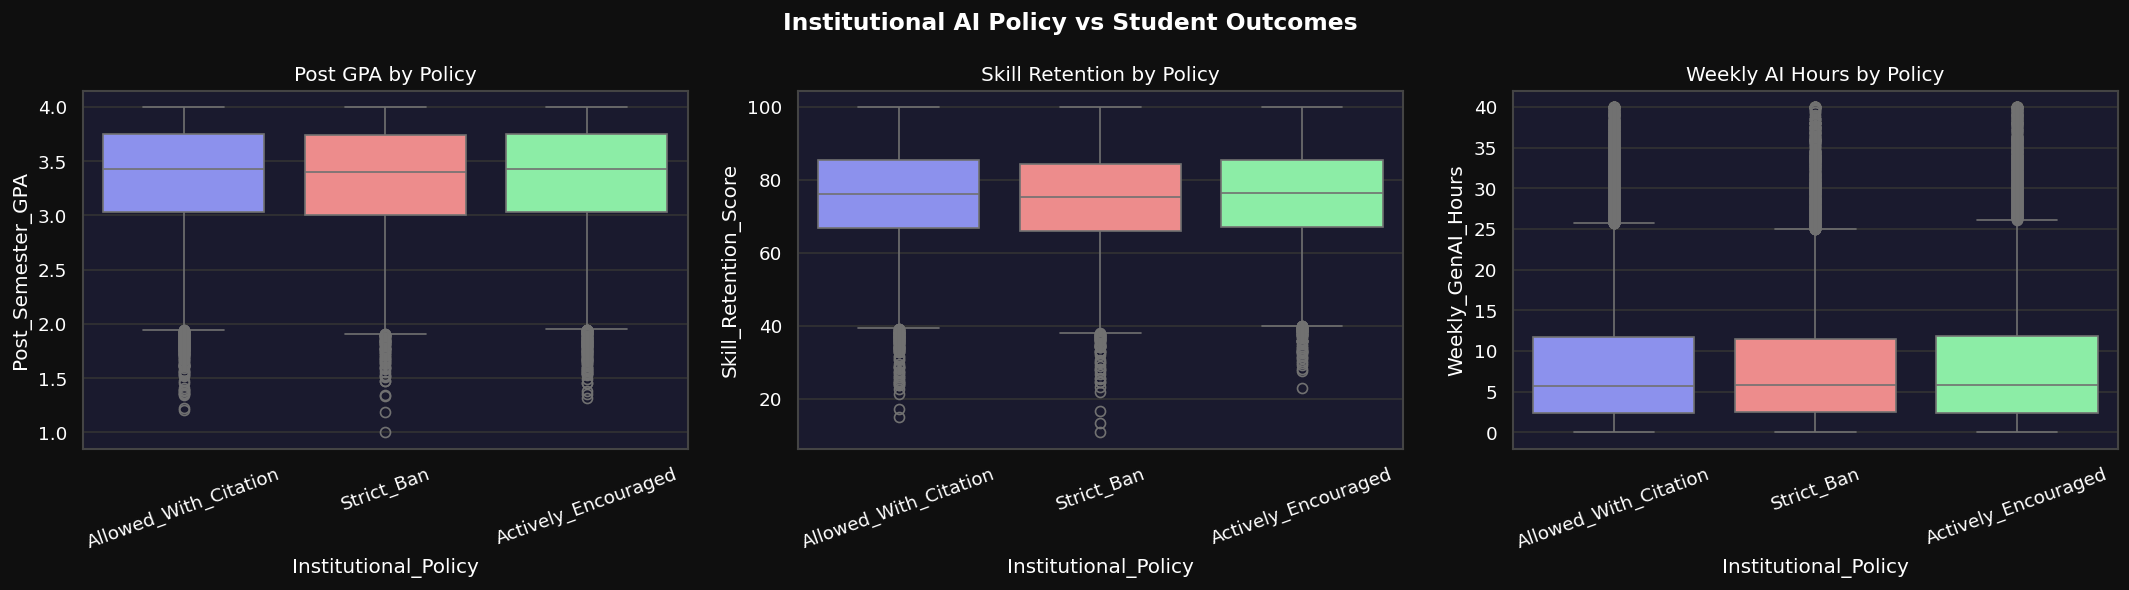

In [17]:
# ── Policy vs outcomes ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Institutional AI Policy vs Student Outcomes", fontsize=14, fontweight="bold")

policies = df["Institutional_Policy"].unique()
colors = [ACCENT[i] for i in range(len(policies))]

# Post GPA by policy
sns.boxplot(data=df, x="Institutional_Policy", y="Post_Semester_GPA",
            palette=ACCENT[:3], ax=axes[0])
axes[0].set_title("Post GPA by Policy")
axes[0].tick_params(axis="x", rotation=20)

# Skill retention by policy
sns.boxplot(data=df, x="Institutional_Policy", y="Skill_Retention_Score",
            palette=ACCENT[:3], ax=axes[1])
axes[1].set_title("Skill Retention by Policy")
axes[1].tick_params(axis="x", rotation=20)

# AI hours by policy
sns.boxplot(data=df, x="Institutional_Policy", y="Weekly_GenAI_Hours",
            palette=ACCENT[:3], ax=axes[2])
axes[2].set_title("Weekly AI Hours by Policy")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


## 🔗 Correlation Analysis

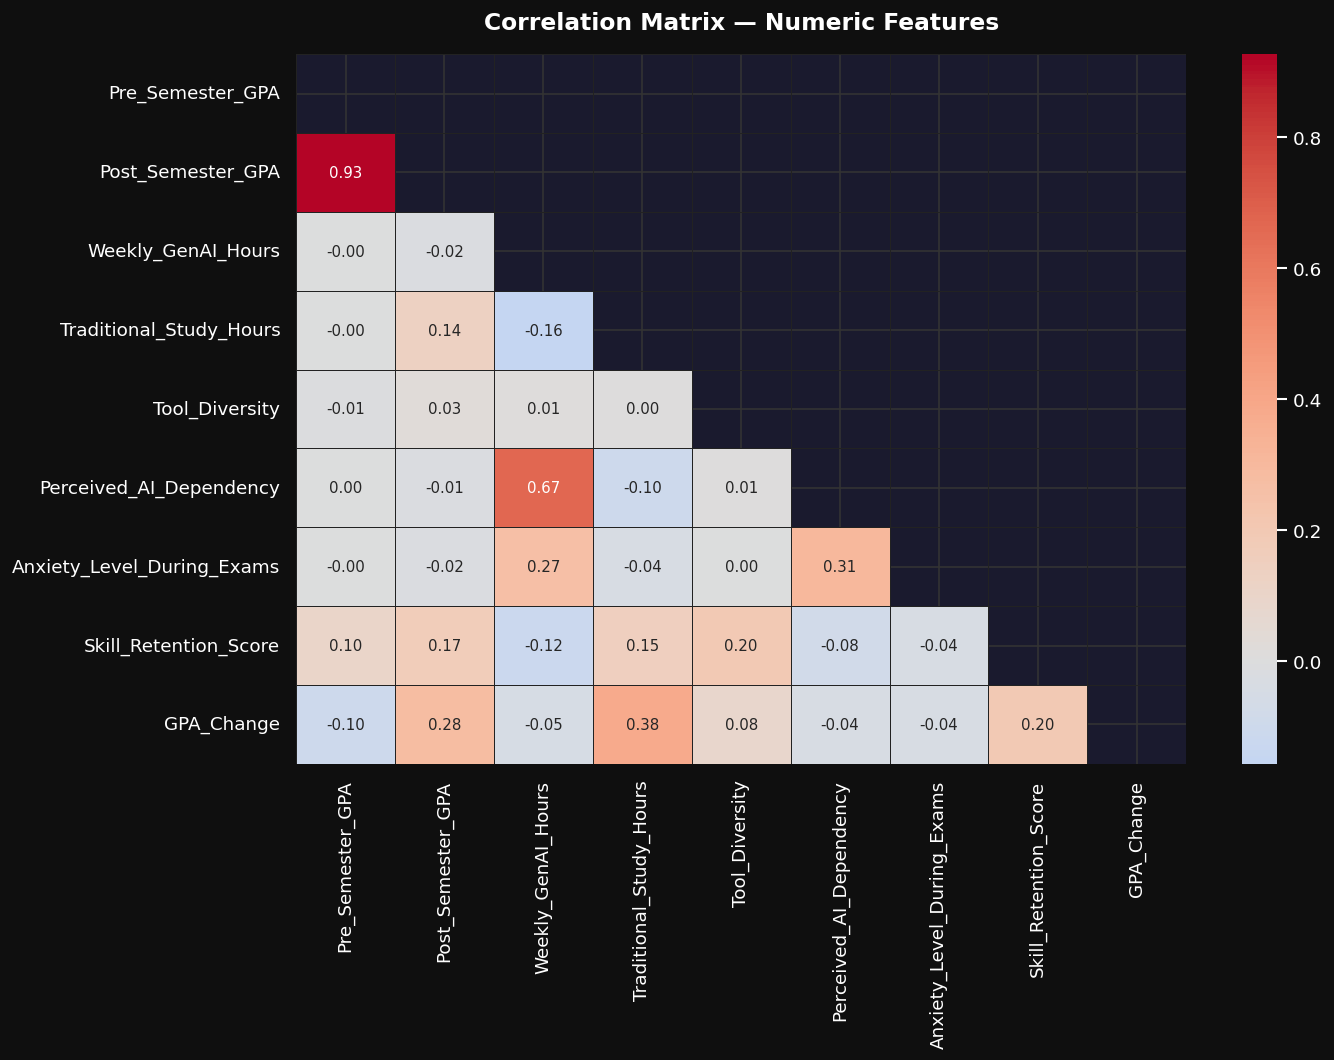

In [18]:
# ── Correlation heatmap ──────────────────────────────────────────────────────
num_df = df[["Pre_Semester_GPA","Post_Semester_GPA","Weekly_GenAI_Hours",
             "Traditional_Study_Hours","Tool_Diversity","Perceived_AI_Dependency",
             "Anxiety_Level_During_Exams","Skill_Retention_Score","GPA_Change"]]

corr = num_df.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, linecolor="#222",
            annot_kws={"size": 9}, ax=ax)
ax.set_title("Correlation Matrix — Numeric Features", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

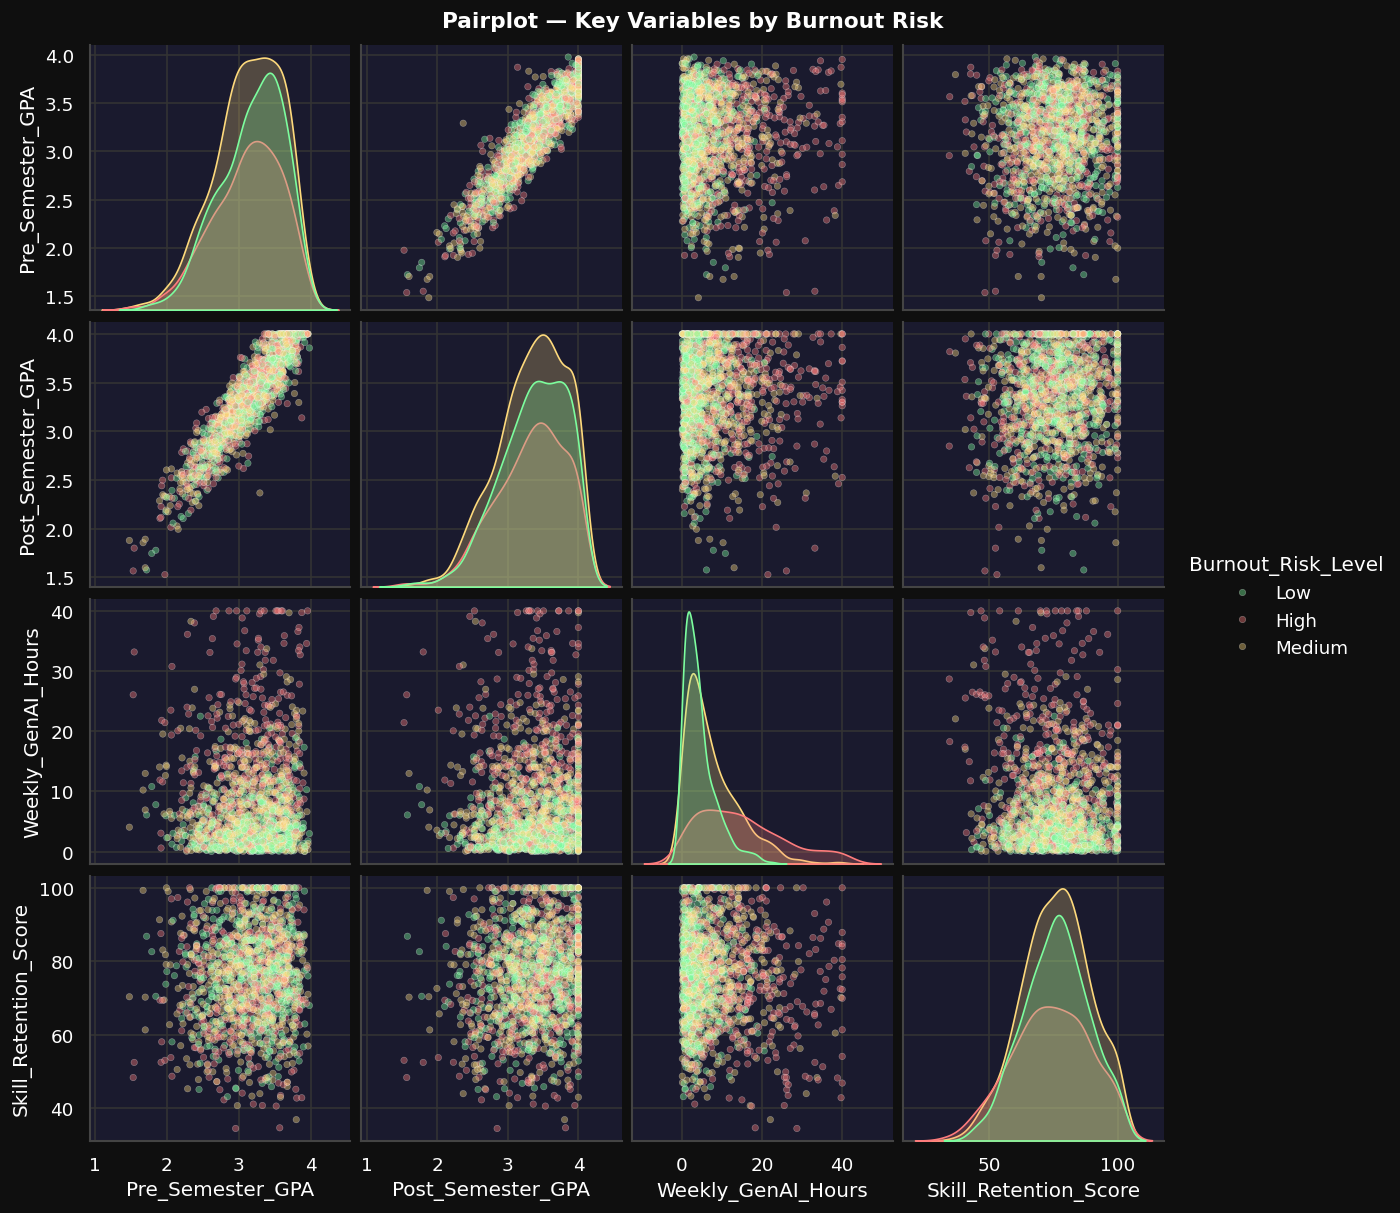

In [19]:
# ── Pairplot of key variables ────────────────────────────────────────────────
key_vars = ["Pre_Semester_GPA","Post_Semester_GPA",
            "Weekly_GenAI_Hours","Skill_Retention_Score","Burnout_Risk_Level"]
sample_pp = df[key_vars].sample(1500, random_state=42)

pp = sns.pairplot(sample_pp, hue="Burnout_Risk_Level",
                  palette=BURNOUT, plot_kws={"alpha":0.4, "s":15},
                  diag_kind="kde")
pp.fig.suptitle("Pairplot — Key Variables by Burnout Risk", y=1.01,
                fontsize=13, fontweight="bold")
plt.show()

## 🎓 Major & Year-wise Deep Dive

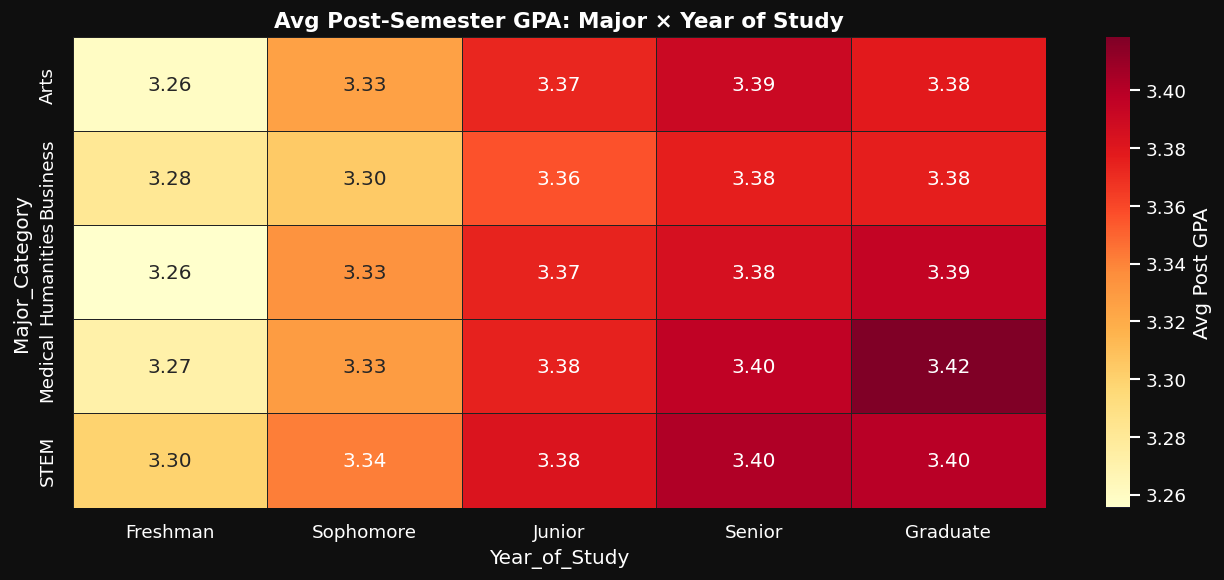

In [20]:
# ── Heatmap: Major × Year → Post GPA ─────────────────────────────────────────
pivot = df.pivot_table(values="Post_Semester_GPA",
                       index="Major_Category",
                       columns="Year_of_Study",
                       aggfunc="mean")[["Freshman","Sophomore","Junior","Senior","Graduate"]]

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.5, linecolor="#222", ax=ax,
            cbar_kws={"label": "Avg Post GPA"})
ax.set_title("Avg Post-Semester GPA: Major × Year of Study",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

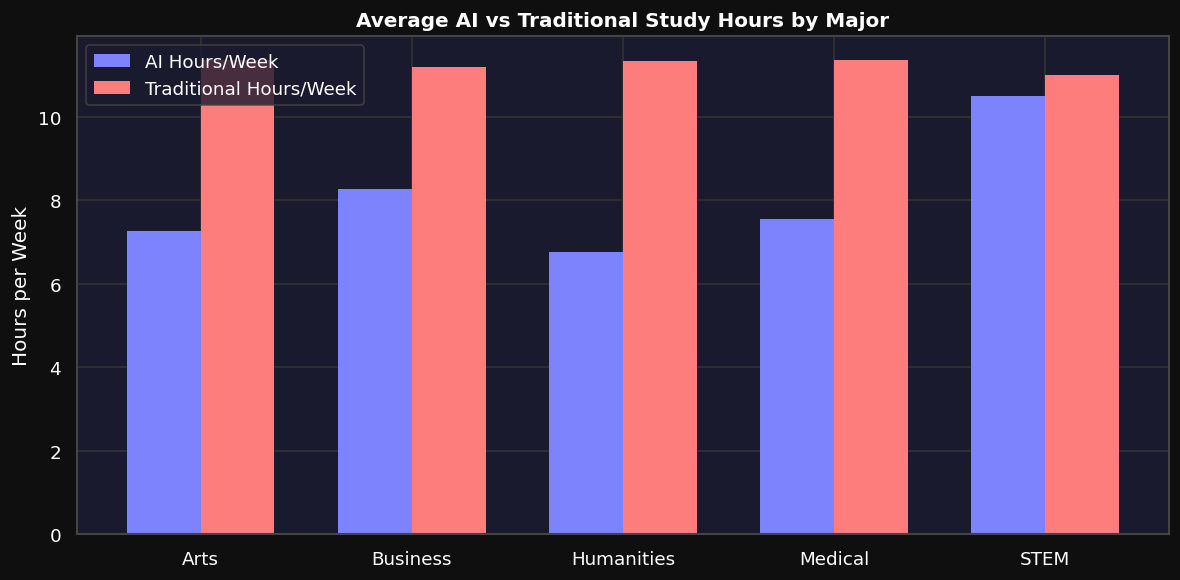

In [21]:
# ── AI hours & Traditional hours by Major ────────────────────────────────────
major_hours = df.groupby("Major_Category")[["Weekly_GenAI_Hours","Traditional_Study_Hours"]].mean()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(major_hours))
w = 0.35
ax.bar(x - w/2, major_hours["Weekly_GenAI_Hours"],  width=w, label="AI Hours/Week",
       color="#7c83fd", edgecolor="none")
ax.bar(x + w/2, major_hours["Traditional_Study_Hours"], width=w, label="Traditional Hours/Week",
       color="#fd7c7c", edgecolor="none")
ax.set_xticks(x)
ax.set_xticklabels(major_hours.index)
ax.set_title("Average AI vs Traditional Study Hours by Major", fontweight="bold")
ax.set_ylabel("Hours per Week")
ax.legend()
plt.tight_layout()
plt.show()

## 🛠️ Primary AI Use Case Analysis

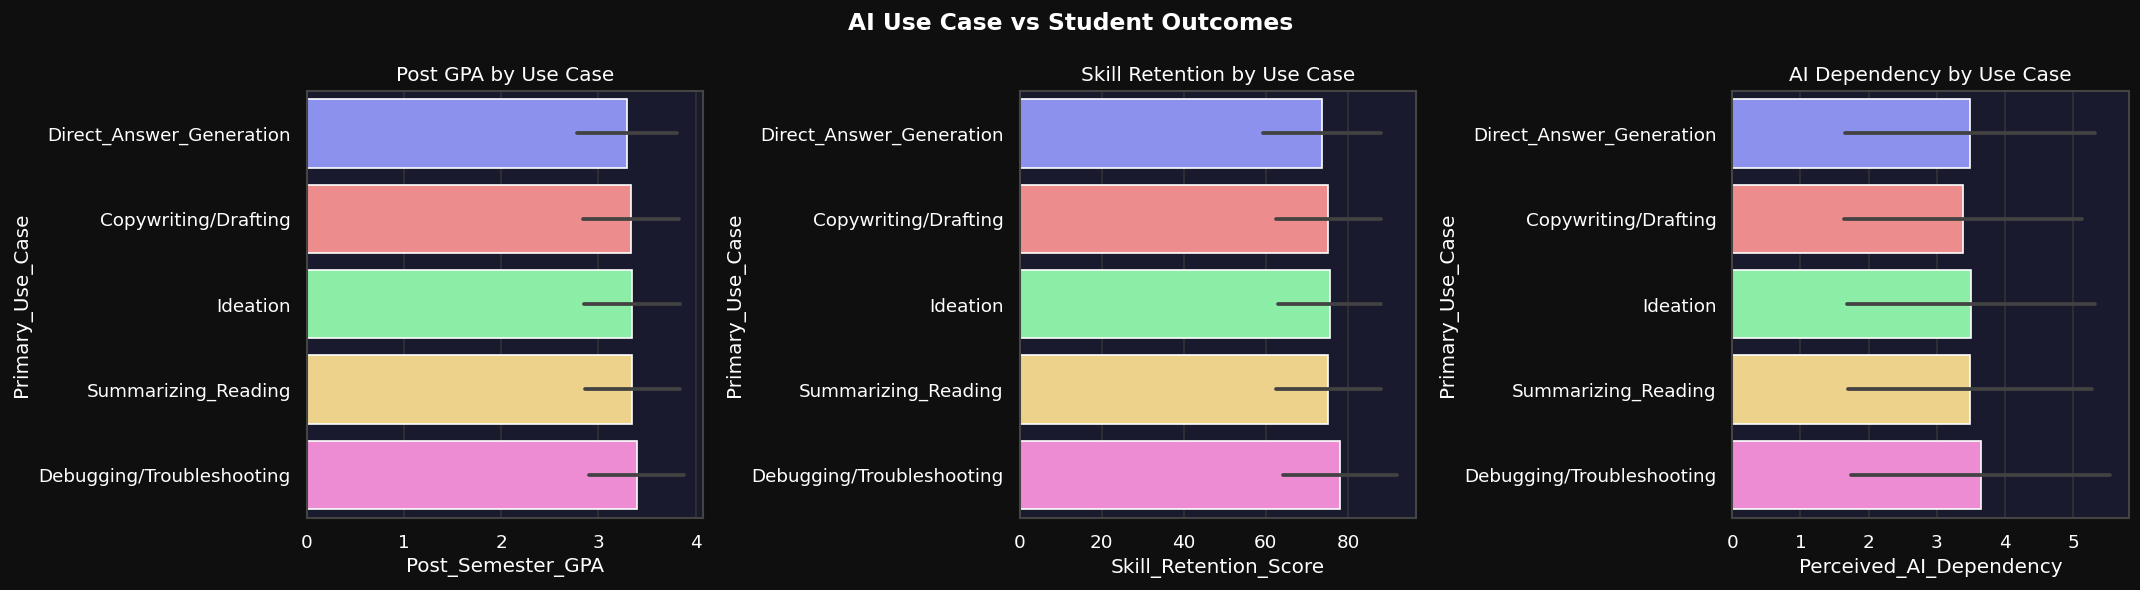

In [22]:
# ── Use case vs outcomes ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("AI Use Case vs Student Outcomes", fontsize=14, fontweight="bold")

use_order = df.groupby("Primary_Use_Case")["Post_Semester_GPA"].mean().sort_values().index

sns.barplot(data=df, x="Post_Semester_GPA", y="Primary_Use_Case",
            order=use_order, palette=ACCENT, ax=axes[0], orient="h", errorbar="sd")
axes[0].set_title("Post GPA by Use Case")

sns.barplot(data=df, x="Skill_Retention_Score", y="Primary_Use_Case",
            order=use_order, palette=ACCENT, ax=axes[1], orient="h", errorbar="sd")
axes[1].set_title("Skill Retention by Use Case")

sns.barplot(data=df, x="Perceived_AI_Dependency", y="Primary_Use_Case",
            order=use_order, palette=ACCENT, ax=axes[2], orient="h", errorbar="sd")
axes[2].set_title("AI Dependency by Use Case")

plt.tight_layout()
plt.show()


## 💡 Key Insights Summary

## Insight

1. Moderate AI usage (5–15 hrs/week) correlates with the best GPA outcomes; heavy usage (30+ hrs) tends to lower scores.

2. Advanced prompt engineering skill is associated with higher Post GPA and better skill retention.

3. Higher AI dependency strongly correlates with elevated burnout risk and exam anxiety.

4. Actively Encouraged policy institutions show higher weekly AI hours but mixed GPA outcomes.

5. STEM students use AI most for debugging; Humanities students lean toward copywriting/drafting.

6. Graduate students show the smallest GPA drop when using AI heavily, suggesting better self-regulation.

7. Tool diversity (3–4 tools) is associated with slightly better academic outcomes than using a single tool.

8. High burnout risk students show significantly higher exam anxiety and perceived AI dependency.

9. Skill retention scores decrease as weekly AI hours increase beyond 20 hrs, hinting at over-reliance.

10. Paid subscription holders tend to use more tools and have slightly higher prompt skill levels.